# 🧠 نظام تشخيص أورام الدماغ
# التصنيف بنموذج TensorFlow (98%) + التجزئة الهجينة (6 مراحل)

---

### ما تم تعديله على كودك الأصلي:
- **التصنيف**: ✅ نفس نموذجك `.h5` بدون أي تغيير
- **`crop_brain_region()`**: ✅ نفس دالتك بالضبط
- **تحديد مكان الورم**: ❌ تم حذف `IntegratedGradientsVisualizer` + `find_tumor_bbox_ig()`
- **البديل الجديد**: ✅ Pipeline هجين من 6 مراحل:

```
┌─────────────────────────────────────────────────────────────────────────┐
│  1. CLAHE (تحسين التباين)                                              │
│  2. Anisotropic Diffusion (إزالة الضوضاء مع حفظ الحواف)              │
│  3. Skull Stripping (إزالة الجمجمة)                                   │
│  4. Otsu Thresholding (التجزئة الأولية)                               │
│  5. Morphological Cleaning (التنظيف المورفولوجي)                      │
│  6. Marker-Controlled Watershed (التجزئة الدقيقة)                     │
│  7. FCM Refinement (تحسين الحدود — اختياري)                           │
│  8. Post-processing (استخراج القناع + BBox + Contour)                 │
└─────────────────────────────────────────────────────────────────────────┘
```

### المراجع:
- Alqhtani et al. (2024) — CLAHE + Diffusion + FCM → DSC=0.961
- Rajini et al. — Threshold + Watershed → TPR > 90%
- PMC10923355 (2024) — Marker-Controlled Watershed + FCM → 100% extraction

---
## الخلية 1: تحميل المكتبات

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os, glob
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
from time import time

plt.rcParams['figure.figsize'] = (18, 5)
plt.rcParams['figure.dpi'] = 100

print(f'✅ TensorFlow: {tf.__version__}')
print(f'✅ OpenCV:     {cv2.__version__}')
print(f'✅ NumPy:      {np.__version__}')

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'✅ GPU: {gpus[0].name}')
else:
    print('⚠️ CPU mode')

✅ TensorFlow: 2.9.0
✅ OpenCV:     4.8.0
✅ NumPy:      1.23.5
✅ GPU: /physical_device:GPU:0


---
## الخلية 2: الإعدادات + تحميل نموذجك (بدون تغيير)

In [2]:
# ═══════════════════════════════════════════
#  من كودك الأصلي — بدون تغيير
# ═══════════════════════════════════════════

MODEL_PATH = 'C:/Users/NARUTO/Downloads/best_model_brain_tumar.h5'

CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
CLASS_NAMES_AR = {
    'glioma':     'ورم دبقي',
    'meningioma': 'ورم سحائي',
    'notumor':    'لا يوجد ورم',
    'pituitary':  'ورم نخامي'
}

model = load_model(MODEL_PATH, compile=False)
print(f'✅ نموذجك: {MODEL_PATH}')
print(f'   Input:  {model.input_shape}')
print(f'   Output: {model.output_shape}')

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3050 Laptop GPU, compute capability 8.6
✅ نموذجك: C:/Users/NARUTO/Downloads/best_model_brain_tumar.h5
   Input:  (None, 224, 224, 3)
   Output: (None, 4)


---
## الخلية 3: دوال من كودك الأصلي (بدون تغيير)

In [3]:
# ═══════════════════════════════════════════
#  من كودك — بدون أي تعديل
# ═══════════════════════════════════════════

def crop_brain_region(image):
    """نفس دالتك بالضبط"""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 45, 255, cv2.THRESH_BINARY)
    kernel = np.ones((3, 3), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
    contours_info = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = contours_info[0] if len(contours_info) == 2 else contours_info[1]
    if not contours:
        return image
    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)
    padding = 10
    x = max(0, x - padding)
    y = max(0, y - padding)
    w = min(image.shape[1] - x, w + 2 * padding)
    h = min(image.shape[0] - y, h + 2 * padding)
    return image[y:y+h, x:x+w]


def classify_image(image, model):
    """نفس طريقة التصنيف من كودك: crop→resize→normalize→predict"""
    cropped = crop_brain_region(image)
    resized = cv2.resize(cropped, (224, 224))
    normalized = resized.astype(np.float32) / 255.0
    predictions = model.predict(np.expand_dims(normalized, 0), verbose=0)[0]
    class_idx = int(np.argmax(predictions))
    return {
        'class': CLASS_NAMES[class_idx],
        'class_ar': CLASS_NAMES_AR[CLASS_NAMES[class_idx]],
        'confidence': float(predictions[class_idx]) * 100,
        'all_probs': predictions,
        'cropped': cropped
    }

print('✅ crop_brain_region() + classify_image() — من كودك')

✅ crop_brain_region() + classify_image() — من كودك


---
## الخلية 4: 🆕 Pipeline التجزئة الهجين الكامل (6 مراحل)

هذا يستبدل:
- `IntegratedGradientsVisualizer` (الكلاس بالكامل)
- `generate_ig()`
- `find_tumor_bbox_ig()`

كل المراحل في دالة واحدة مع عرض مخرجات كل مرحلة.

In [4]:
# ═══════════════════════════════════════════════════════════════════════
#  🆕 Pipeline التجزئة الهجين — يستبدل IntegratedGradientsVisualizer
# ═══════════════════════════════════════════════════════════════════════
#
#  ما تم حذفه من كودك:
#    class IntegratedGradientsVisualizer   ← حُذف بالكامل
#    def find_tumor_bbox_ig()              ← حُذف بالكامل
#
#  ما تم إضافته بدلاً منهما:
#    def segment_tumor_hybrid()            ← 6 مراحل كلاسيكية
# ═══════════════════════════════════════════════════════════════════════


def segment_tumor_hybrid(image, use_fcm=True, verbose=False):
    """
    Pipeline التجزئة الهجين — 6 مراحل
    يستبدل generate_ig() + find_tumor_bbox_ig() من كودك
    
    المراحل:
      1. CLAHE (تحسين التباين المحلي)
      2. Anisotropic Diffusion (إزالة الضوضاء مع حفظ الحواف)
      3. Skull Stripping (إزالة الجمجمة)
      4. Otsu + Morphological Cleaning (التجزئة الأولية)
      5. Marker-Controlled Watershed (التجزئة الدقيقة)
      6. FCM Refinement (تحسين الحدود — اختياري)
    
    Returns: dict مع كل المخرجات
    """
    start = time()
    stages = {}  # لحفظ مخرجات كل مرحلة للعرض
    
    # ── تحضير الصورة الرمادية ──
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image.copy()
    stages['original'] = gray.copy()
    
    
    # ════════════════════════════════════════════
    #  المرحلة 1: CLAHE — تحسين التباين المحلي
    # ════════════════════════════════════════════
    #  يقسم الصورة لمربعات 8×8 ويعادل الهيستوغرام
    #  في كل مربع مع سقف clipLimit=3.0
    #  أفضل من Histogram Equalization العادي للأورام
    #  لأن الورم منطقة محلية صغيرة
    # ════════════════════════════════════════════
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(cv2.GaussianBlur(gray, (5, 5), 0))
    stages['clahe'] = enhanced.copy()
    if verbose: print('  ✅ 1. CLAHE')
    
    
    # ════════════════════════════════════════════
    #  المرحلة 2: Anisotropic Diffusion (Perona-Malik)
    # ════════════════════════════════════════════
    #  يزيل الضوضاء مع الحفاظ على حواف الورم
    #  المعادلة: ∂I/∂t = div[c(|∇I|)·∇I]
    #  دالة التوصيل: c = exp(-(|∇I|/κ)²)
    #  - عند الحواف: |∇I| كبير → c صغير → لا انتشار (حفظ)
    #  - في المناطق المتجانسة: |∇I| صغير → c كبير → تنعيم
    # ════════════════════════════════════════════
    img_f = enhanced.astype(np.float64)
    for _ in range(10):  # iterations=10, kappa=50, gamma=0.125
        dN = np.roll(img_f, -1, axis=0) - img_f
        dS = np.roll(img_f,  1, axis=0) - img_f
        dE = np.roll(img_f,  1, axis=1) - img_f
        dW = np.roll(img_f, -1, axis=1) - img_f
        img_f += 0.125 * (
            np.exp(-(dN/50)**2)*dN + np.exp(-(dS/50)**2)*dS +
            np.exp(-(dE/50)**2)*dE + np.exp(-(dW/50)**2)*dW
        )
    diffused = np.clip(img_f, 0, 255).astype(np.uint8)
    stages['diffusion'] = diffused.copy()
    if verbose: print('  ✅ 2. Anisotropic Diffusion')
    
    
    # ════════════════════════════════════════════
    #  المرحلة 3: Skull Stripping — إزالة الجمجمة
    # ════════════════════════════════════════════
    #  نبحث عن أكبر مكون متصل (الدماغ) ونزيل الباقي
    #  هذا يمنع اكتشاف حواف الجمجمة كورم
    # ════════════════════════════════════════════
    _, skull_th = cv2.threshold(diffused, 30, 255, cv2.THRESH_BINARY)
    k_skull = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    skull_mask = cv2.morphologyEx(skull_th, cv2.MORPH_CLOSE, k_skull, iterations=3)
    skull_mask = cv2.morphologyEx(skull_mask, cv2.MORPH_OPEN, k_skull, iterations=2)
    cnts_skull, _ = cv2.findContours(skull_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if cnts_skull:
        brain_mask = np.zeros_like(skull_mask)
        cv2.drawContours(brain_mask, [max(cnts_skull, key=cv2.contourArea)], -1, 255, -1)
    else:
        brain_mask = skull_mask
    skull_stripped = cv2.bitwise_and(diffused, diffused, mask=brain_mask)
    stages['skull_stripped'] = skull_stripped.copy()
    if verbose: print('  ✅ 3. Skull Stripping')
    
    
    # ════════════════════════════════════════════
    #  المرحلة 4: Otsu Thresholding + تنظيف مورفولوجي
    # ════════════════════════════════════════════
    #  Otsu يحسب العتبة المثلى تلقائياً بتعظيم التباين
    #  ثم Multi-Otsu: عتبة ثانية أعلى لعزل المناطق الساطعة
    #  ثم Opening (إزالة ضوضاء) + Closing (ملء ثقوب)
    #  ثم حذف المكونات الصغيرة (< 1% من الصورة)
    # ════════════════════════════════════════════
    otsu_val = cv2.threshold(skull_stripped, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[0]
    high_th = min(otsu_val * 1.3, 250)
    _, otsu_mask = cv2.threshold(skull_stripped, int(high_th), 255, cv2.THRESH_BINARY)
    
    # تنظيف مورفولوجي
    k_s = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    k_m = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    cleaned = cv2.morphologyEx(otsu_mask, cv2.MORPH_OPEN, k_s, iterations=2)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, k_m, iterations=3)
    
    # حذف المكونات الصغيرة
    n_lab, labels, stats, _ = cv2.connectedComponentsWithStats(cleaned, 8)
    min_area = cleaned.shape[0] * cleaned.shape[1] * 0.01
    morph_mask = np.zeros_like(cleaned)
    for i in range(1, n_lab):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            morph_mask[labels == i] = 255
    
    stages['otsu'] = otsu_mask.copy()
    stages['morphology'] = morph_mask.copy()
    if verbose: print('  ✅ 4. Otsu + Morphology')
    
    # fallback: إذا لم يبقَ شيء بعد التنظيف
    if np.sum(morph_mask) == 0:
        _, morph_mask = cv2.threshold(skull_stripped, 0, 255,
                                      cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        morph_mask = cv2.morphologyEx(morph_mask, cv2.MORPH_OPEN, k_s, iterations=1)
        n_lab, labels, stats, _ = cv2.connectedComponentsWithStats(morph_mask, 8)
        temp = np.zeros_like(morph_mask)
        for i in range(1, n_lab):
            if stats[i, cv2.CC_STAT_AREA] >= min_area:
                temp[labels == i] = 255
        if np.sum(temp) > 0:
            morph_mask = temp
    
    
    # ════════════════════════════════════════════
    #  المرحلة 5: Marker-Controlled Watershed
    # ════════════════════════════════════════════
    #  تشبيه: الصورة = تضاريس، البكسلات المشرقة = قمم
    #  نملأ الأحواض بالماء → السدود = حدود التجزئة
    #
    #  الخطوات:
    #  1. Sure Background = توسيع القناع (Dilation)
    #  2. Distance Transform = المسافة لأقرب حد
    #  3. Sure Foreground = العتبة على المسافات (المراكز)
    #  4. Unknown = الفرق بينهما
    #  5. Markers + cv2.watershed()
    # ════════════════════════════════════════════
    watershed_mask = morph_mask.copy()
    
    if np.sum(morph_mask) > 0:
        img_color = image if len(image.shape) == 3 else cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
        k_ws = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        
        sure_bg = cv2.dilate(morph_mask, k_ws, iterations=5)
        dist_transform = cv2.distanceTransform(morph_mask, cv2.DIST_L2, 5)
        
        max_dist = dist_transform.max()
        if max_dist > 0:
            _, sure_fg = cv2.threshold(dist_transform, 0.5 * max_dist, 255, 0)
            sure_fg = np.uint8(sure_fg)
            unknown = cv2.subtract(sure_bg, sure_fg)
            
            n_markers, markers = cv2.connectedComponents(sure_fg)
            markers = markers + 1
            markers[unknown == 255] = 0
            markers = cv2.watershed(img_color.copy(), markers)
            
            ws_result = np.zeros_like(morph_mask)
            ws_result[markers > 1] = 255
            
            # تصفية: الاحتفاظ بمكونات بحجم معقول
            total_px = ws_result.shape[0] * ws_result.shape[1]
            n2, lb2, st2, _ = cv2.connectedComponentsWithStats(ws_result, 8)
            refined = np.zeros_like(ws_result)
            for i in range(1, n2):
                a = st2[i, cv2.CC_STAT_AREA]
                if 0.005 * total_px < a < 0.5 * total_px:
                    refined[lb2 == i] = 255
            
            if np.sum(refined) > 0:
                watershed_mask = refined
    
    stages['watershed'] = watershed_mask.copy()
    stages['dist_transform'] = dist_transform if np.sum(morph_mask) > 0 and max_dist > 0 else np.zeros_like(gray)
    if verbose: print('  ✅ 5. Watershed')
    
    
    # ════════════════════════════════════════════
    #  المرحلة 6: FCM Refinement (اختياري)
    # ════════════════════════════════════════════
    #  FCM = Fuzzy C-Means: كل بكسل ينتمي لأكثر من مجموعة
    #  بدرجات عضوية (0 إلى 1)
    #  u_ij = 1 / Σ_k (d_ij/d_ik)^(2/(m-1))
    #  مفيد للحدود الضبابية بين الورم والأنسجة الطبيعية
    # ════════════════════════════════════════════
    final_mask = watershed_mask.copy()
    
    if use_fcm and np.sum(watershed_mask) > 0:
        # توسيع ROI
        k_roi = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
        roi_mask = cv2.dilate(watershed_mask, k_roi, iterations=3)
        roi_pixels = gray[roi_mask > 0].flatten().astype(np.float64)
        
        if len(roi_pixels) >= 100:
            n_clusters, m = 3, 2.0
            centers = np.linspace(roi_pixels.min(), roi_pixels.max(), n_clusters)
            n_px = len(roi_pixels)
            power = 2.0 / (m - 1.0)
            
            for _ in range(50):
                dist = np.maximum(np.abs(roi_pixels[:, None] - centers[None, :]), 1e-10)
                membership = np.zeros((n_px, n_clusters))
                for j in range(n_clusters):
                    denom = np.sum((dist[:, j:j+1] / dist) ** power, axis=1)
                    membership[:, j] = 1.0 / denom
                new_c = np.array([np.sum(membership[:,j]**m * roi_pixels) / np.sum(membership[:,j]**m)
                                  for j in range(n_clusters)])
                if np.max(np.abs(new_c - centers)) < 1e-5:
                    break
                centers = new_c
            
            tumor_cluster = np.argmax(centers)
            fcm_refined = np.zeros_like(gray, dtype=np.uint8)
            roi_idx = np.where(roi_mask > 0)
            tumor_px = membership[:, tumor_cluster] > 0.5
            px_vals = np.zeros(n_px, dtype=np.uint8)
            px_vals[tumor_px] = 255
            fcm_refined[roi_idx] = px_vals
            
            combined = cv2.bitwise_and(fcm_refined, watershed_mask)
            if np.sum(combined) > 0:
                final_mask = combined
        
        if verbose: print('  ✅ 6. FCM Refinement')
    elif verbose:
        print('  ⏭️ 6. FCM — تم التخطي')
    
    stages['fcm'] = final_mask.copy()
    
    
    # ════════════════════════════════════════════
    #  ما بعد المعالجة: أكبر مكون + تنعيم + صور العرض
    # ════════════════════════════════════════════
    # أكبر مكون متصل
    n_final, lb_final, st_final, _ = cv2.connectedComponentsWithStats(final_mask, 8)
    best_mask = np.zeros_like(final_mask)
    best_area = 0
    for i in range(1, n_final):
        if st_final[i, cv2.CC_STAT_AREA] > best_area:
            best_area = st_final[i, cv2.CC_STAT_AREA]
            best_mask = np.zeros_like(final_mask)
            best_mask[lb_final == i] = 255
    
    # تنعيم
    if best_area > 0:
        k_smooth = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        best_mask = cv2.morphologyEx(best_mask, cv2.MORPH_CLOSE, k_smooth)
        best_mask = cv2.GaussianBlur(best_mask, (3, 3), 0)
        _, best_mask = cv2.threshold(best_mask, 127, 255, cv2.THRESH_BINARY)
    
    tumor_found = best_area > 0
    total_px = gray.shape[0] * gray.shape[1]
    
    # صور العرض
    display = image if len(image.shape) == 3 else cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    
    overlay = display.copy()
    contour_img = display.copy()
    bbox = None
    center = None
    
    if tumor_found:
        # Overlay
        clr = np.zeros_like(display)
        clr[best_mask > 0] = [0, 0, 255]
        overlay = cv2.addWeighted(display, 0.7, clr, 0.3, 0)
        
        # Contour + BBox
        cnts, _ = cv2.findContours(best_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if cnts:
            cv2.drawContours(contour_img, cnts, -1, (0, 255, 0), 2)
            largest = max(cnts, key=cv2.contourArea)
            bbox = cv2.boundingRect(largest)
            x, y, w, h = bbox
            cv2.rectangle(contour_img, (x, y), (x+w, y+h), (255, 255, 0), 2)
            cv2.putText(contour_img, 'Tumor', (x, y-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)
            M = cv2.moments(largest)
            if M['m00'] > 0:
                center = (int(M['m10']/M['m00']), int(M['m01']/M['m00']))
                cv2.circle(contour_img, center, 5, (0, 0, 255), -1)
    
    proc_time = round(time() - start, 3)
    if verbose: print(f'  ⏱️ الوقت: {proc_time}s')
    
    return {
        'tumor_mask': best_mask,
        'overlay': overlay,
        'contour_image': contour_img,
        'bbox': bbox,
        'tumor_center': center,
        'tumor_area': int(np.sum(best_mask > 0)),
        'tumor_pct': round((np.sum(best_mask > 0) / total_px) * 100, 2),
        'tumor_found': tumor_found,
        'time': proc_time,
        'stages': stages  # مخرجات كل مرحلة
    }


print('✅ segment_tumor_hybrid() — يستبدل IntegratedGradientsVisualizer بالكامل')

✅ segment_tumor_hybrid() — يستبدل IntegratedGradientsVisualizer بالكامل


---
## الخلية 5: الدالة الرئيسية — تصنيف (نموذجك) + تجزئة (هجين)

In [5]:
# ═══════════════════════════════════════════════════
#  الدالة الرئيسية: نموذجك (تصنيف) + الجديد (تجزئة)
# ═══════════════════════════════════════════════════

def analyze_brain_mri(image, model, use_fcm=True):
    """
    في كودك القديم:
      crop → resize → normalize → ig_viz.generate_ig() → find_tumor_bbox_ig()
    
    الآن:
      crop → classify_image(model)         [نموذجك — لم يتغير]
      crop → segment_tumor_hybrid()        [6 مراحل — جديد]
    """
    t = time()
    
    cls = classify_image(image, model)
    cropped = cls['cropped']
    
    if cls['class'] != 'notumor':
        seg = segment_tumor_hybrid(cropped, use_fcm=use_fcm, verbose=True)
    else:
        h, w = cropped.shape[:2]
        disp = cropped if len(cropped.shape)==3 else cv2.cvtColor(cropped, cv2.COLOR_GRAY2BGR)
        gr = cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY) if len(cropped.shape)==3 else cropped
        seg = {
            'tumor_mask': np.zeros((h,w), np.uint8),
            'overlay': disp.copy(), 'contour_image': disp.copy(),
            'bbox': None, 'tumor_center': None,
            'tumor_area': 0, 'tumor_pct': 0, 'tumor_found': False, 'time': 0,
            'stages': {'original': gr, 'clahe': gr, 'diffusion': gr,
                       'skull_stripped': gr, 'otsu': np.zeros((h,w),np.uint8),
                       'morphology': np.zeros((h,w),np.uint8),
                       'watershed': np.zeros((h,w),np.uint8),
                       'dist_transform': np.zeros((h,w)),
                       'fcm': np.zeros((h,w),np.uint8)}
        }
        print('  🟢 التصنيف: لا يوجد ورم — تم تخطي التجزئة')
    
    return {'classification': cls, 'segmentation': seg, 'cropped': cropped,
            'total_time': round(time()-t, 3)}

print('✅ analyze_brain_mri()')

✅ analyze_brain_mri()


---
## الخلية 6: دوال العرض

In [6]:
def display_full_pipeline(result, title=''):
    """عرض شامل: التصنيف + جميع مراحل التجزئة"""
    cls = result['classification']
    seg = result['segmentation']
    st = seg['stages']
    
    main_title = f"{title}\n{cls['class_ar']} — {cls['confidence']:.1f}% — {result['total_time']}s"
    
    # ══ الصف 1: المراحل 1-4 ══
    fig, axes = plt.subplots(2, 4, figsize=(20, 9))
    fig.suptitle(main_title, fontsize=14, fontweight='bold', y=1.02)
    
    axes[0,0].imshow(st['original'], cmap='gray')
    axes[0,0].set_title('1. الأصلية', fontweight='bold'); axes[0,0].axis('off')
    
    axes[0,1].imshow(st['clahe'], cmap='gray')
    axes[0,1].set_title('2. CLAHE', fontweight='bold'); axes[0,1].axis('off')
    
    axes[0,2].imshow(st['diffusion'], cmap='gray')
    axes[0,2].set_title('3. Diffusion', fontweight='bold'); axes[0,2].axis('off')
    
    axes[0,3].imshow(st['skull_stripped'], cmap='gray')
    axes[0,3].set_title('4. Skull Stripped', fontweight='bold'); axes[0,3].axis('off')
    
    # ══ الصف 2: المراحل 5-8 ══
    axes[1,0].imshow(st['morphology'], cmap='gray')
    axes[1,0].set_title('5. Otsu + Morphology', fontweight='bold'); axes[1,0].axis('off')
    
    axes[1,1].imshow(st['watershed'], cmap='gray')
    axes[1,1].set_title('6. Watershed', fontweight='bold'); axes[1,1].axis('off')
    
    axes[1,2].imshow(cv2.cvtColor(seg['overlay'], cv2.COLOR_BGR2RGB))
    axes[1,2].set_title('7. Overlay', fontweight='bold'); axes[1,2].axis('off')
    
    axes[1,3].imshow(cv2.cvtColor(seg['contour_image'], cv2.COLOR_BGR2RGB))
    axes[1,3].set_title('8. Contour + BBox', fontweight='bold'); axes[1,3].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # ══ المعلومات ══
    print(f"{'═'*60}")
    print(f"🏷️ التصنيف (نموذجك): {cls['class_ar']} ({cls['confidence']:.1f}%)")
    if seg['tumor_found']:
        print(f"🔴 التجزئة: المساحة={seg['tumor_area']}px | النسبة={seg['tumor_pct']}%")
        if seg['bbox']:
            x,y,w,h = seg['bbox']
            print(f"   📍 BBox: ({x},{y}) {w}×{h} | المركز: {seg['tumor_center']}")
    else:
        print(f"🟢 لا يوجد ورم")
    print(f"⏱️ التجزئة: {seg['time']}s | الكلي: {result['total_time']}s")
    
    print(f"\n📊 احتمالات نموذجك:")
    for i, c in enumerate(CLASS_NAMES):
        p = cls['all_probs'][i] * 100
        bar = '█' * int(p/3)
        m = ' ◀' if c == cls['class'] else ''
        print(f"  {CLASS_NAMES_AR[c]:12s} {bar} {p:.1f}%{m}")
    print(f"{'═'*60}")

print('✅ display_full_pipeline()')

✅ display_full_pipeline()


---
## ▶️ الخلية 7: اختبار على صورة واحدة

In [ ]:
image_path = r"C:\Users\NARUTO\Downloads\archive (3)\Testing\meningioma\Te-me_0020.jpg"# ← مسار صورتك

if os.path.exists(image_path):
    img = cv2.imread(image_path)
    result = analyze_brain_mri(img, model, use_fcm=True)
    display_full_pipeline(result, title=os.path.basename(image_path))
else:
    print(f'⚠️ عدّل image_path — أو استخدم الخلية التالية للرفع')

In [8]:
# رفع صورة (Google Colab)
try:
    from google.colab import files
    uploaded = files.upload()
    for fname in uploaded:
        nparr = np.frombuffer(uploaded[fname], np.uint8)
        img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
        result = analyze_brain_mri(img, model, use_fcm=True)
        display_full_pipeline(result, title=fname)
except ImportError:
    print('💡 Google Colab فقط')

💡 Google Colab فقط


---
## ▶️ الخلية 8: اختبار على مجلد صور

  ✅ 1. CLAHE
  ✅ 2. Anisotropic Diffusion
  ✅ 3. Skull Stripping
  ✅ 4. Otsu + Morphology
  ✅ 5. Watershed
  ✅ 6. FCM Refinement
  ⏱️ الوقت: 0.34s


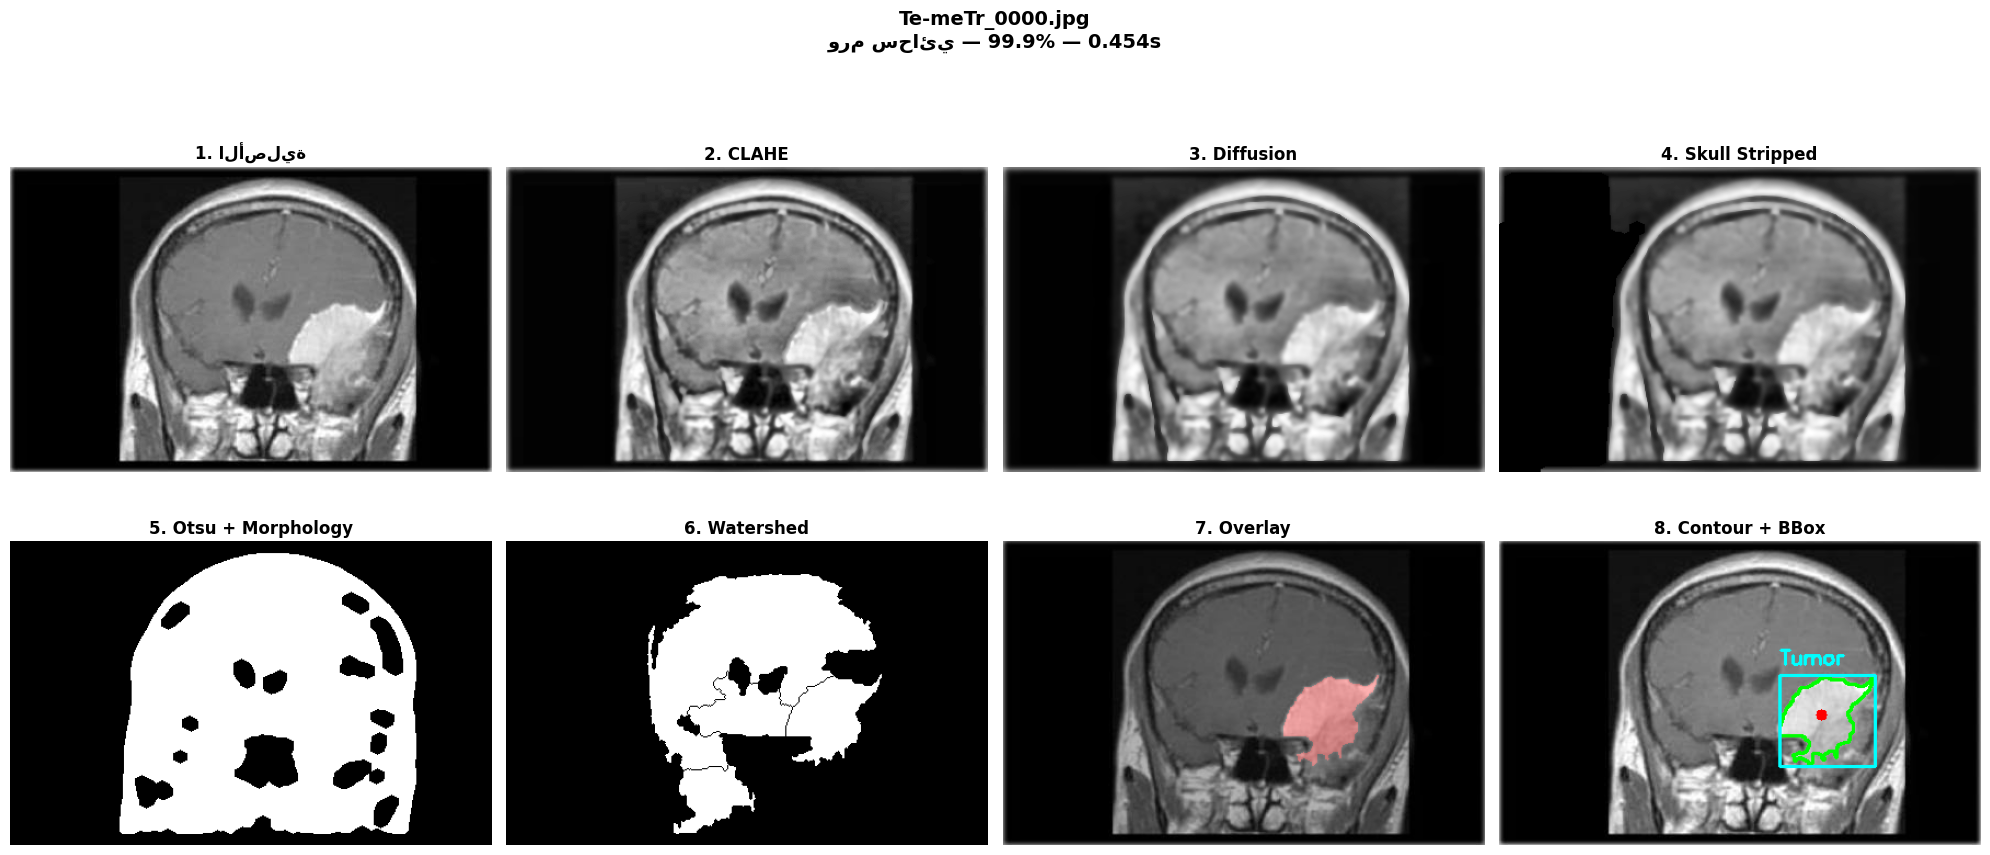

════════════════════════════════════════════════════════════
🏷️ التصنيف (نموذجك): ورم سحائي (99.9%)
🔴 التجزئة: المساحة=3832px | النسبة=3.13%
   📍 BBox: (256,123) 87×83 | المركز: (294, 159)
⏱️ التجزئة: 0.34s | الكلي: 0.454s

📊 احتمالات نموذجك:
  ورم دبقي      0.0%
  ورم سحائي    █████████████████████████████████ 99.9% ◀
  لا يوجد ورم   0.1%
  ورم نخامي     0.0%
════════════════════════════════════════════════════════════

  ✅ 1. CLAHE
  ✅ 2. Anisotropic Diffusion
  ✅ 3. Skull Stripping
  ✅ 4. Otsu + Morphology
  ✅ 5. Watershed
  ✅ 6. FCM Refinement
  ⏱️ الوقت: 0.303s


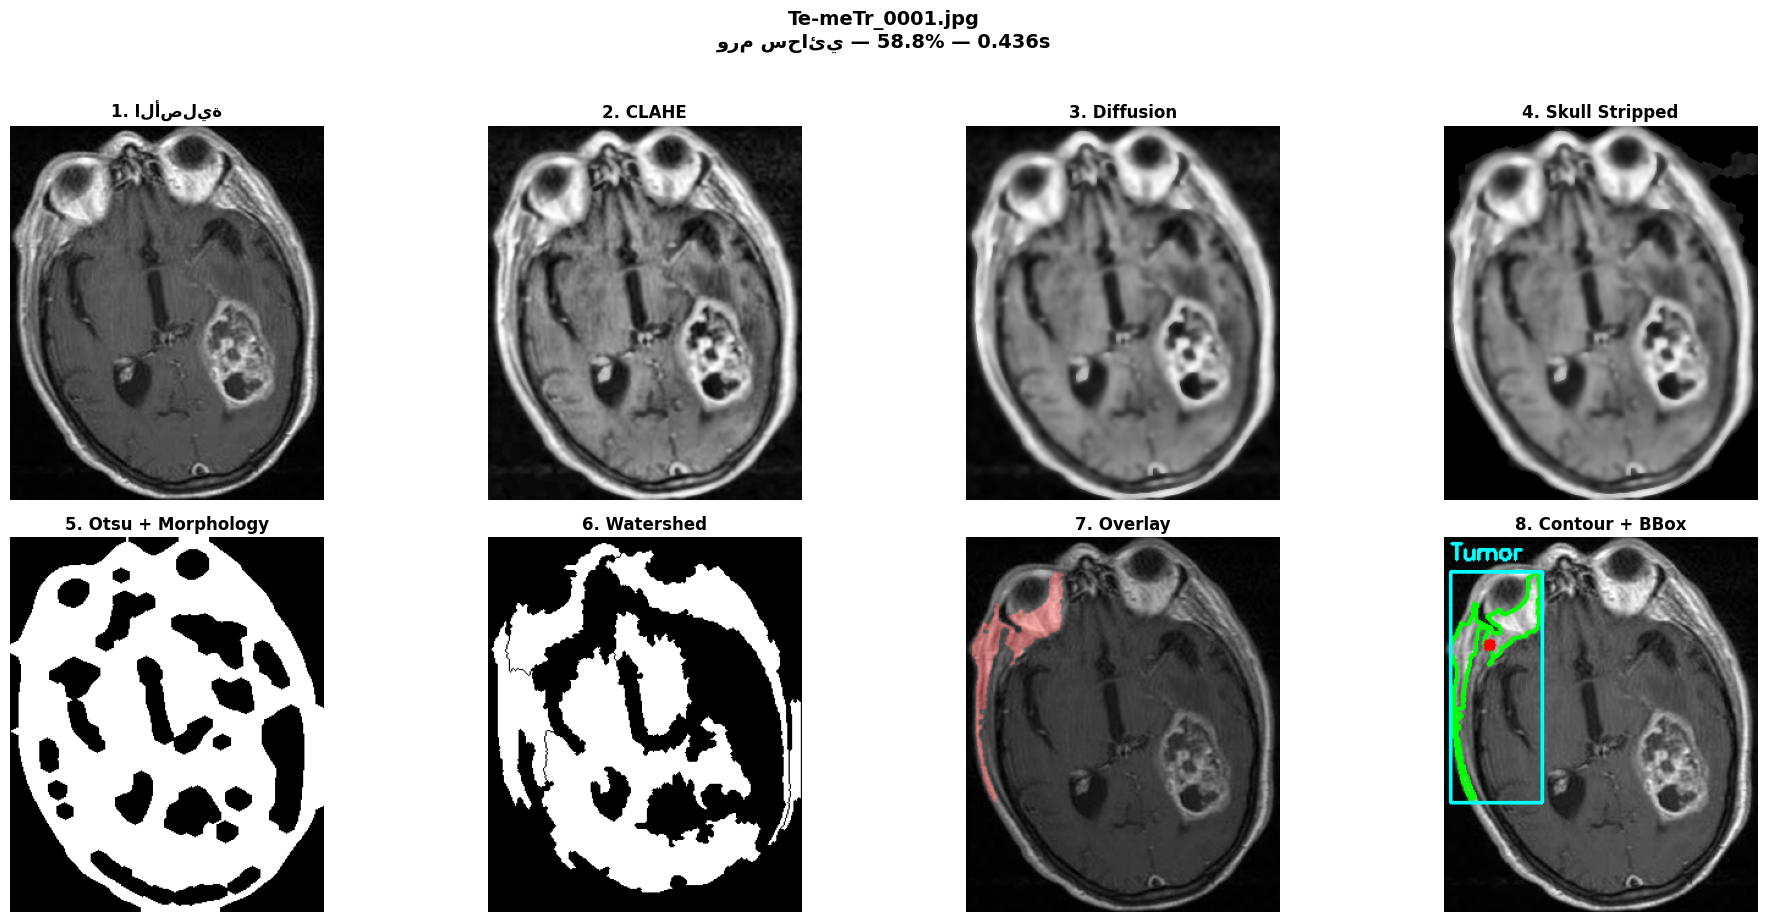

════════════════════════════════════════════════════════════
🏷️ التصنيف (نموذجك): ورم سحائي (58.8%)
🔴 التجزئة: المساحة=2772px | النسبة=3.51%
   📍 BBox: (5,28) 75×189 | المركز: (37, 88)
⏱️ التجزئة: 0.303s | الكلي: 0.436s

📊 احتمالات نموذجك:
  ورم دبقي     █ 5.5%
  ورم سحائي    ███████████████████ 58.8% ◀
  لا يوجد ورم   0.7%
  ورم نخامي    ███████████ 35.0%
════════════════════════════════════════════════════════════

  ✅ 1. CLAHE
  ✅ 2. Anisotropic Diffusion
  ✅ 3. Skull Stripping
  ✅ 4. Otsu + Morphology
  ✅ 5. Watershed
  ✅ 6. FCM Refinement
  ⏱️ الوقت: 0.08s


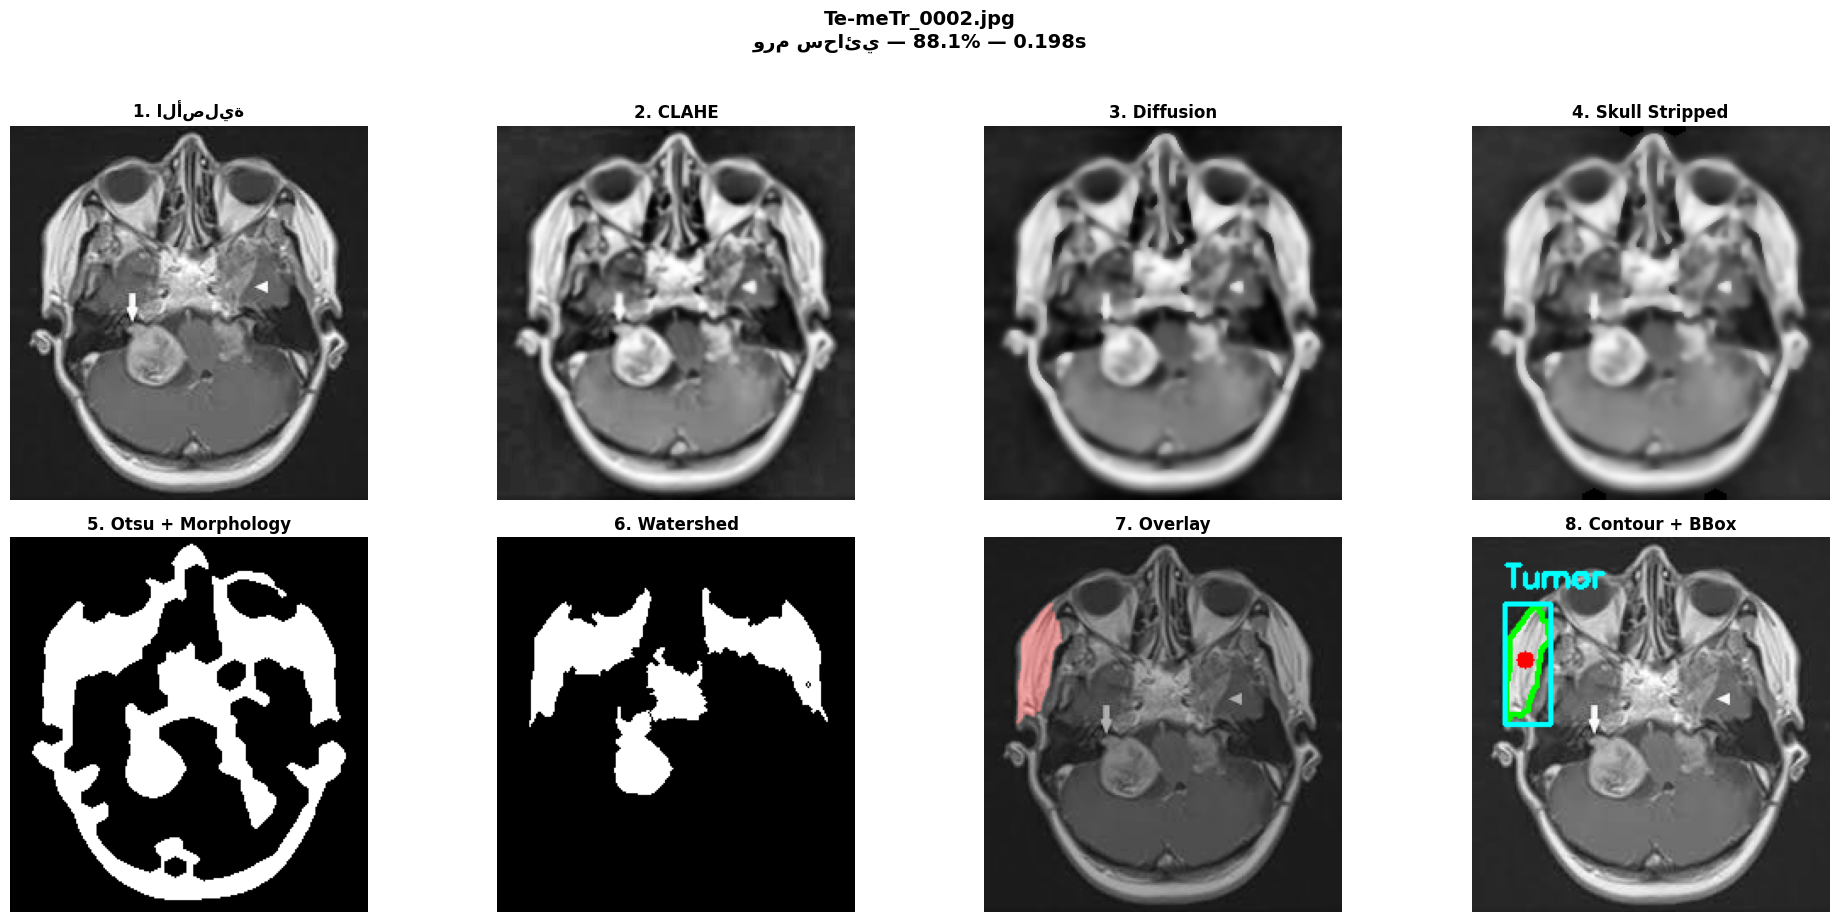

════════════════════════════════════════════════════════════
🏷️ التصنيف (نموذجك): ورم سحائي (88.1%)
🔴 التجزئة: المساحة=1093px | النسبة=2.34%
   📍 BBox: (19,39) 27×71 | المركز: (31, 72)
⏱️ التجزئة: 0.08s | الكلي: 0.198s

📊 احتمالات نموذجك:
  ورم دبقي      0.0%
  ورم سحائي    █████████████████████████████ 88.1% ◀
  لا يوجد ورم  ███ 11.7%
  ورم نخامي     0.1%
════════════════════════════════════════════════════════════

  ✅ 1. CLAHE
  ✅ 2. Anisotropic Diffusion
  ✅ 3. Skull Stripping
  ✅ 4. Otsu + Morphology
  ✅ 5. Watershed
  ✅ 6. FCM Refinement
  ⏱️ الوقت: 0.156s


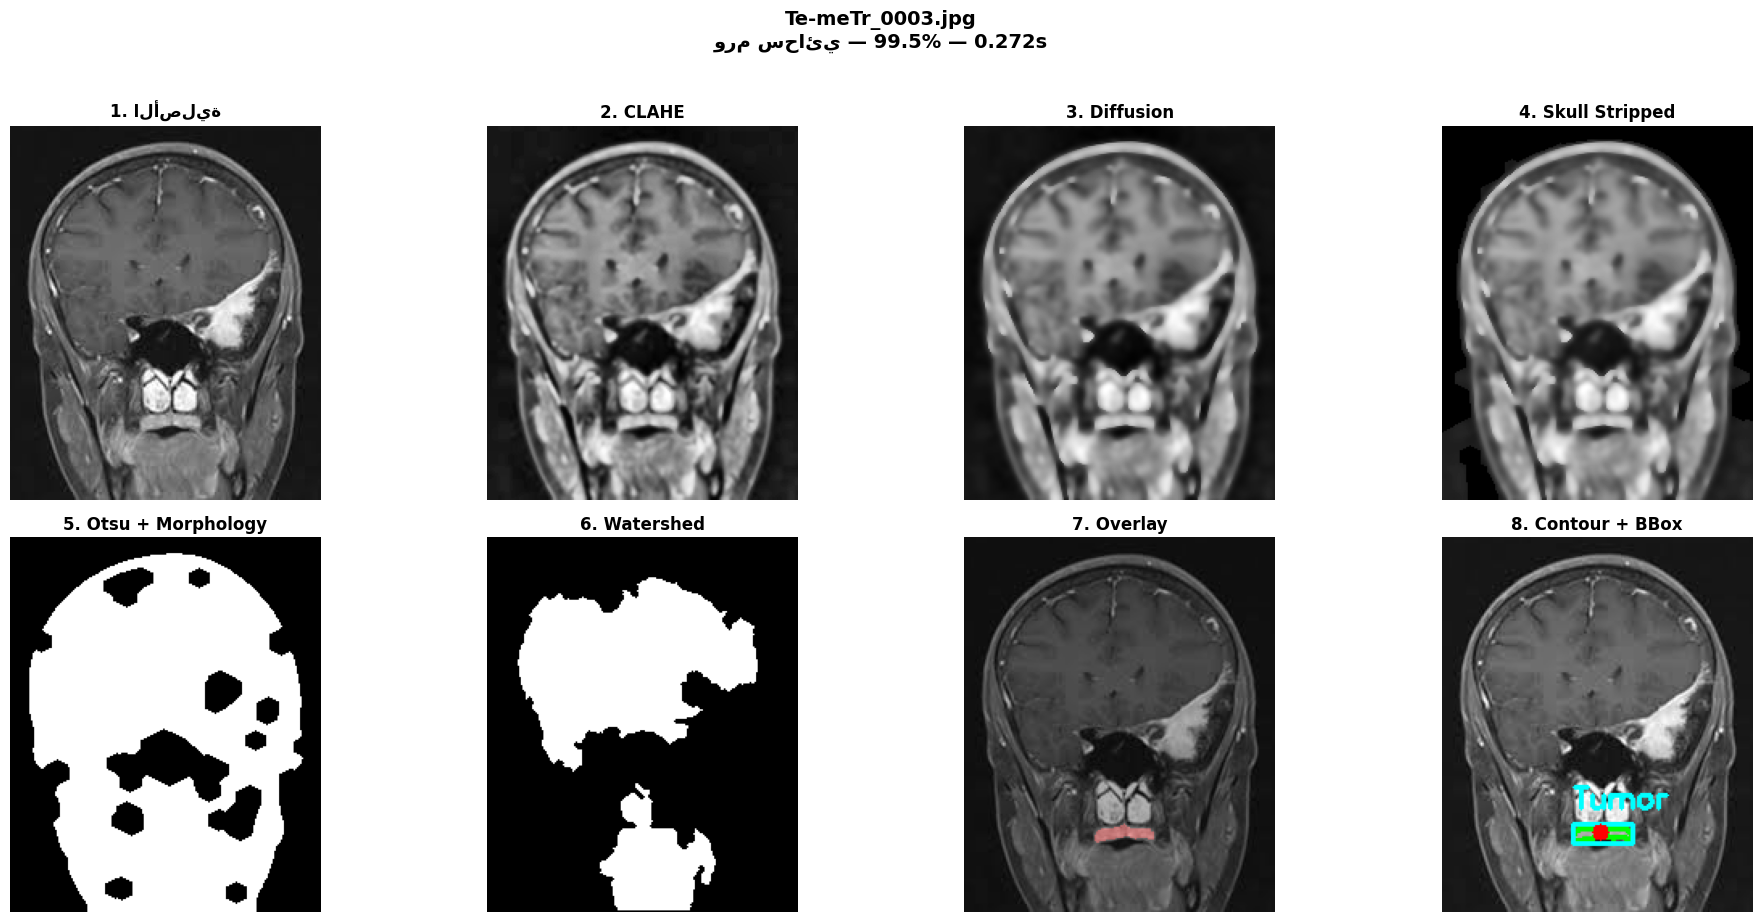

════════════════════════════════════════════════════════════
🏷️ التصنيف (نموذجك): ورم سحائي (99.5%)
🔴 التجزئة: المساحة=248px | النسبة=0.55%
   📍 BBox: (81,178) 37×12 | المركز: (98, 183)
⏱️ التجزئة: 0.156s | الكلي: 0.272s

📊 احتمالات نموذجك:
  ورم دبقي      0.1%
  ورم سحائي    █████████████████████████████████ 99.5% ◀
  لا يوجد ورم   0.4%
  ورم نخامي     0.0%
════════════════════════════════════════════════════════════

  ✅ 1. CLAHE
  ✅ 2. Anisotropic Diffusion
  ✅ 3. Skull Stripping
  ✅ 4. Otsu + Morphology
  ✅ 5. Watershed
  ✅ 6. FCM Refinement
  ⏱️ الوقت: 1.372s


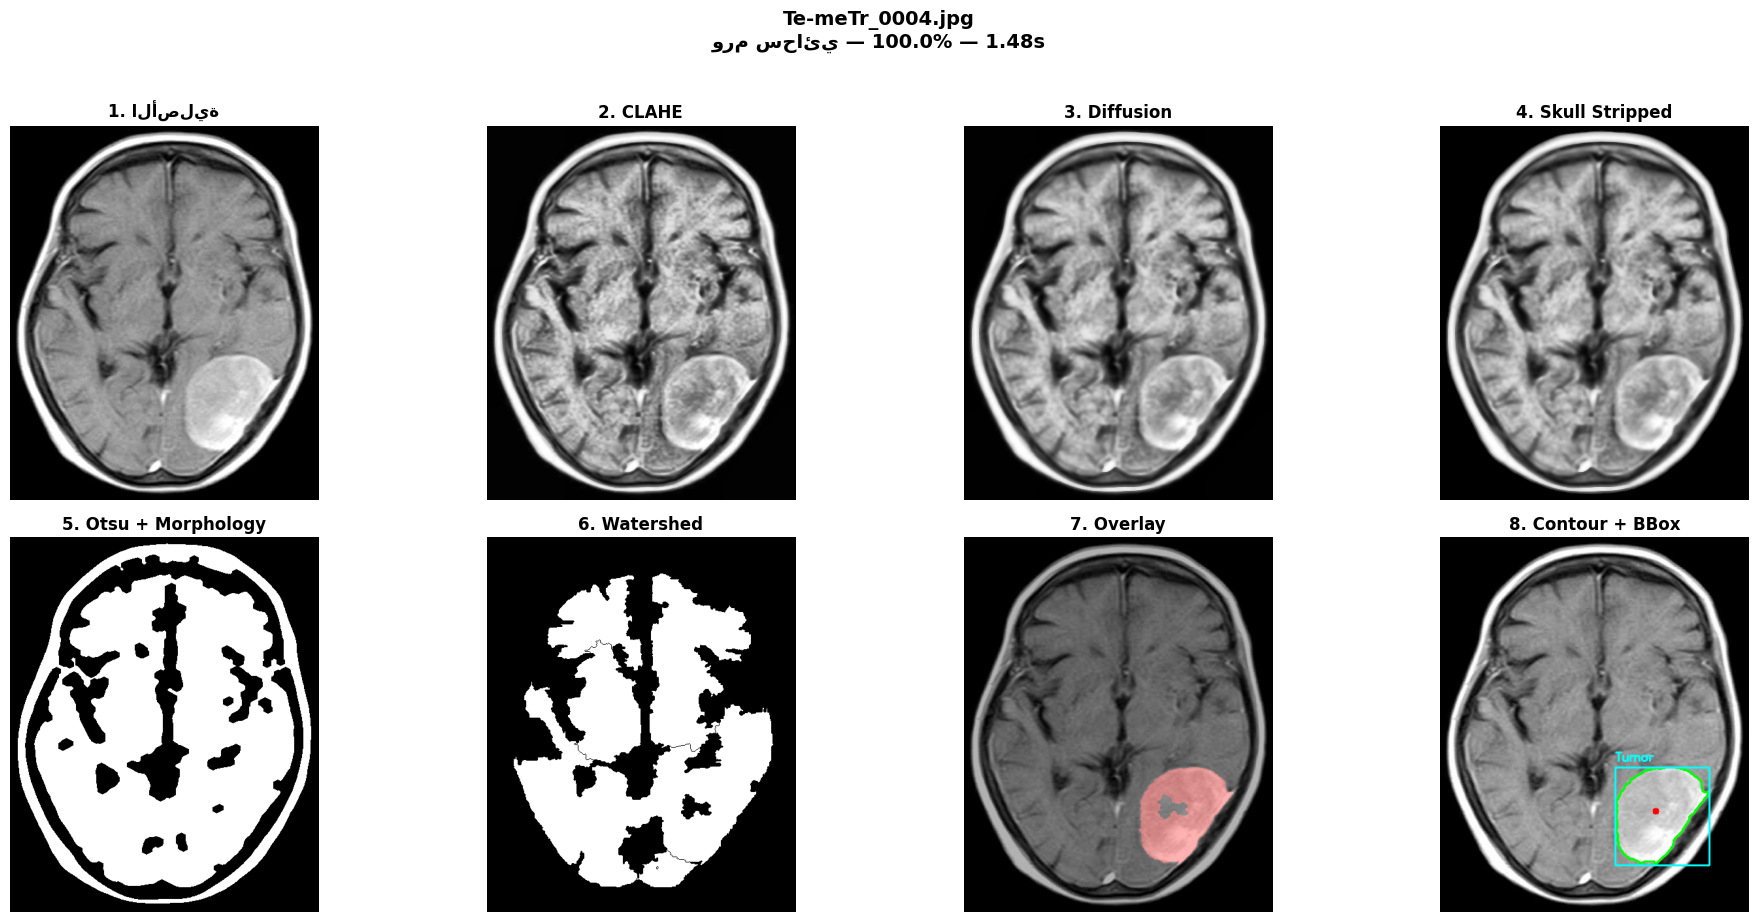

════════════════════════════════════════════════════════════
🏷️ التصنيف (نموذجك): ورم سحائي (100.0%)
🔴 التجزئة: المساحة=13489px | النسبة=4.96%
   📍 BBox: (268,353) 144×150 | المركز: (330, 420)
⏱️ التجزئة: 1.372s | الكلي: 1.48s

📊 احتمالات نموذجك:
  ورم دبقي      0.0%
  ورم سحائي    █████████████████████████████████ 100.0% ◀
  لا يوجد ورم   0.0%
  ورم نخامي     0.0%
════════════════════════════════════════════════════════════



In [9]:
TEST_DIR = r"C:\Users\NARUTO\Downloads\archive (3)\Testing\meningioma"  # ← عدّل المسار

if os.path.exists(TEST_DIR):
    files = glob.glob(os.path.join(TEST_DIR, '**', '*.jpg'), recursive=True)
    files += glob.glob(os.path.join(TEST_DIR, '**', '*.png'), recursive=True)
    
    for fpath in files[:5]:
        img = cv2.imread(fpath)
        if img is None: continue
        result = analyze_brain_mri(img, model)
        display_full_pipeline(result, title=os.path.basename(fpath))
        print()
else:
    print(f'⚠️ المجلد غير موجود: {TEST_DIR}')

---
## 📝 ملخص التغييرات على كودك

### ✅ لم يتغير:
| من كودك | الحالة |
|---------|--------|
| `MODEL_PATH` | ✅ نفسه |
| `CLASS_NAMES` + `CLASS_NAMES_AR` | ✅ نفسها |
| `crop_brain_region()` | ✅ نسخة طبق الأصل |
| `model.predict(normalized)` | ✅ نفس المعالجة |
| النموذج `.h5` (98% دقة) | ✅ لم يُمس |

### ❌ تم حذفه:
| من كودك | السبب |
|---------|-------|
| `class IntegratedGradientsVisualizer` | استُبدل بالتجزئة الكلاسيكية |
| `generate_ig()` | استُبدل بـ `segment_tumor_hybrid()` |
| `find_tumor_bbox_ig()` | مُدمجة داخل `segment_tumor_hybrid()` |

### 🆕 تم إضافته:
| الدالة | الوظيفة |
|--------|--------|
| `segment_tumor_hybrid()` | Pipeline الـ 6 مراحل بالكامل |

### الخوارزميات الـ 6:
| # | الخوارزمية | ماذا تفعل |
|---|-----------|----------|
| 1 | CLAHE | تحسين التباين المحلي |
| 2 | Anisotropic Diffusion | إزالة ضوضاء مع حفظ الحواف |
| 3 | Skull Stripping | إزالة الجمجمة |
| 4 | Otsu + Morphology | تجزئة أولية + تنظيف |
| 5 | Marker-Controlled Watershed | تجزئة دقيقة بالعلامات |
| 6 | FCM Refinement | تحسين الحدود الضبابية |